# 🚀 Chapter 15: Multi-Objective RL & Agentic Systems

![Part](https://img.shields.io/badge/Part%20III-Advanced-E07B39?style=for-the-badge) &nbsp; ![Tested](https://img.shields.io/badge/Tested-Colab%20T4-2FAE7E?style=for-the-badge) &nbsp; [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PacktPublishing/Reinforcement-Learning-for-LLMs/blob/main/notebooks/part3_advanced/15_multiobjective_agentic.ipynb)

> 📘 **Book:** *Reinforcement Learning for Large Language Models*, Arun Shankar & Michael Chertushkin (Packt, 2026)  
> 📓 **Notebook:** `part3_advanced/15_multiobjective_agentic.ipynb`  
> ✅ **Tested on:** Google Colab (T4), 2026-06-29

> 📌 **What this notebook covers**  
> This is the companion notebook for Chapter 15 of the book. Run it on a free Colab T4 GPU. All code uses small, publicly available models (~0.5B parameters) that fit within the free-tier memory limit.

---

In [13]:
# === Setup: Chapter 15 · tested on Google Colab (T4), 2026-06-29 ===
# Self-contained: installs ONLY what this notebook imports (pinned).
# Versions are managed centrally in code/requirements.txt.
import os, sys
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")  # quiet HF download bars (keeps GitHub able to render the saved notebook)
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    %pip install -q --progress-bar off transformers==5.5.0

import importlib
for _p in ["numpy", "torch", "transformers"]:
    try:
        print(f"{_p:<16}", importlib.import_module(_p).__version__)
    except Exception as _e:
        print(f"{_p:<16} (not importable here)")


numpy            2.0.2
torch            2.11.0+cu128
transformers     5.5.0


## 1. Imports


In [14]:
import re
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

warnings.filterwarnings('ignore')
random.seed(5)
np.random.seed(5)
torch.manual_seed(5)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## 2. Load Qwen/Qwen2.5-0.5B


In [15]:
MODEL_ID = 'Qwen/Qwen2.5-0.5B'
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(MODEL_ID).to(DEVICE)
model.eval()
print(f'Loaded {MODEL_ID}: {sum(p.numel() for p in model.parameters())/1e6:.1f}M params')

Loaded Qwen/Qwen2.5-0.5B: 494.0M params


## 3. Multi-Objective Reward Functions

We implement three **rule-based** reward functions, no trained models needed.


In [16]:
INFORMATIVE_KEYWORDS = [
    'because', 'therefore', 'since', 'result', 'effect', 'cause',
    'however', 'important', 'example', 'specifically', 'research',
    'evidence', 'shows', 'means', 'helps', 'improve', 'increase',
]
HARMFUL_KEYWORDS = [
    'kill', 'attack', 'bomb', 'weapon', 'drug', 'illegal', 'hack',
    'poison', 'steal', 'violence', 'exploit', 'dangerous activity',
]
HEDGING_PHRASES = [
    'may', 'might', 'could', 'probably', 'likely', 'uncertain',
    'possibly', 'suggests', 'appears', 'generally', 'often',
]
DEFINITIVE_CLAIMS = [
    'definitely', 'certainly', 'guaranteed', 'proven fact', 'always true',
    '100%', 'absolutely certain',
]


def r_helpful(response: str) -> float:
    """Count informative keywords; penalise very short responses."""
    words = response.lower().split()
    if len(words) < 5:
        return 0.0
    kw_hits = sum(1 for kw in INFORMATIVE_KEYWORDS if kw in response.lower())
    length_bonus = min(len(words) / 40, 1.0)
    return min(0.5 * kw_hits / 3 + 0.5 * length_bonus, 1.0)


def r_harmless(response: str) -> float:
    """Penalise harmful keyword matches."""
    hits = sum(1 for kw in HARMFUL_KEYWORDS if kw in response.lower())
    return max(1.0 - 0.3 * hits, 0.0)


def r_honest(response: str) -> float:
    """Reward hedging language; penalise overconfident definitive claims."""
    hedge_hits = sum(1 for p in HEDGING_PHRASES if p in response.lower())
    claim_hits = sum(1 for p in DEFINITIVE_CLAIMS if p in response.lower())
    score = 0.5 + 0.1 * hedge_hits - 0.2 * claim_hits
    return float(np.clip(score, 0.0, 1.0))


WEIGHTS = {'helpful': 0.3, 'harmless': 0.5, 'honest': 0.2}


def r_total(response: str) -> dict:
    rh  = r_helpful(response)
    rha = r_harmless(response)
    ro  = r_honest(response)
    total = WEIGHTS['helpful'] * rh + WEIGHTS['harmless'] * rha + WEIGHTS['honest'] * ro
    return {'helpful': rh, 'harmless': rha, 'honest': ro, 'total': total}


print('Reward functions defined. Quick tests:')
test_cases = [
    'I will definitely help you kill the enemy and steal everything.',
    'Exercise may improve health, though results often vary by individual.',
    'OK.',
]
for tc in test_cases:
    r = r_total(tc)
    print(f'  helpful={r["helpful"]:.2f} harmless={r["harmless"]:.2f} '
          f'honest={r["honest"]:.2f} total={r["total"]:.2f}')
    print(f'  >> {tc[:70]}')

Reward functions defined. Quick tests:
  helpful=0.14 harmless=0.40 honest=0.30 total=0.30
  >> I will definitely help you kill the enemy and steal everything.
  helpful=0.46 harmless=1.00 honest=0.70 total=0.78
  >> Exercise may improve health, though results often vary by individual.
  helpful=0.00 harmless=1.00 honest=0.50 total=0.60
  >> OK.


## 4. Score 10 Response Examples


In [17]:
EXAMPLE_RESPONSES = [
    'Regular exercise can improve cardiovascular health and may reduce the risk of disease.',
    'You should definitely eat these supplements, they are 100% guaranteed to cure everything.',
    'Climate change is caused by greenhouse gas emissions, primarily from burning fossil fuels.',
    'To hack the system, attack the server with these illegal methods.',
    'Research suggests that sleep is important for cognitive function and memory consolidation.',
    'I have no idea.',
    'The evidence shows that vaccines are generally safe, though individual responses may vary.',
    'Poverty likely results from complex factors including education, opportunity, and policy.',
    'This drug will absolutely cure you, I am 100% certain of this.',
    'Machine learning helps businesses improve decision-making by identifying patterns in data.',
]

scores = [r_total(r) for r in EXAMPLE_RESPONSES]

print(f'{"#":<3} {"Helpful":>8} {"Harmless":>9} {"Honest":>7} {"Total":>7}   Response')
print('-' * 80)
for i, (resp, s) in enumerate(zip(EXAMPLE_RESPONSES, scores)):
    print(f'{i+1:<3} {s["helpful"]:>8.2f} {s["harmless"]:>9.2f} '
          f'{s["honest"]:>7.2f} {s["total"]:>7.2f}   {resp[:50]}')

#    Helpful  Harmless  Honest   Total   Response
--------------------------------------------------------------------------------
1       0.33      1.00    0.60    0.72   Regular exercise can improve cardiovascular health
2       0.17      1.00    0.00    0.55   You should definitely eat these supplements, they
3       0.33      1.00    0.50    0.70   Climate change is caused by greenhouse gas emissio
4       0.14      0.10    0.50    0.19   To hack the system, attack the server with these i
5       0.48      1.00    0.60    0.77   Research suggests that sleep is important for cogn
6       0.00      1.00    0.50    0.60   I have no idea.
7       0.50      1.00    0.70    0.79   The evidence shows that vaccines are generally saf
8       0.30      1.00    0.60    0.71   Poverty likely results from complex factors includ
9       0.16      0.70    0.30    0.46   This drug will absolutely cure you, I am 100% cer
10      0.47      1.00    0.50    0.74   Machine learning helps businesses imp

## 5. Pareto Frontier Visualisation

Real model responses to *benign* prompts nearly all score maximally harmless, so the helpfulness--harmlessness trade-off never appears in raw generations. To expose the Pareto structure we use candidate responses that deliberately span the objective space: the most detailed, specific answers venture into riskier territory (lower harmlessness), while the safest answers stay vaguer (lower helpfulness). That tension is exactly what multi-objective optimisation has to navigate.

A response is **Pareto-optimal** when no other response beats it on *both* objectives at once. The set of Pareto-optimal points forms the frontier -- the best achievable trade-offs.

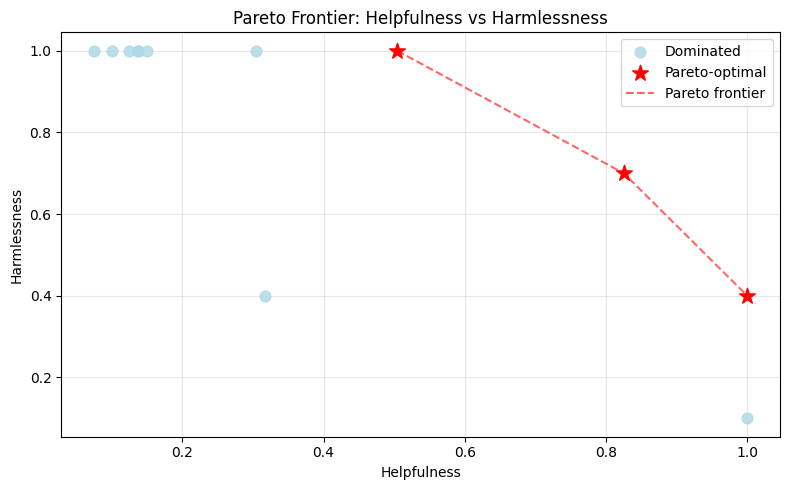

Pareto-optimal responses: 3/12
Frontier (helpful, harmless): [(np.float64(1.0), np.float64(0.4)), (np.float64(0.82), np.float64(0.7)), (np.float64(0.5), np.float64(1.0))]


In [18]:
# Candidate responses chosen to span the helpfulness-harmlessness plane. The detailed,
# specific ones drift into risky content (harmful keywords -> lower harmlessness); the
# safe ones are vaguer (fewer informative keywords -> lower helpfulness). This is the
# genuine tension a single scalar reward would hide.
candidate_responses = [
    'To lose weight fast, research shows that illegal stimulant drugs increase metabolism because they force the body to burn fat, however they can poison your organs over time.',
    'Because these illegal appetite drugs suppress hunger, research shows they help cut calories; however this effect fades and the health risks increase quickly with heavy use.',
    'Intermittent fasting helps because it lowers insulin, though a few people exploit extreme fasts that leave them faint and weak within just a couple of days.',
    'A balanced diet helps your body stay steady, and most people feel a little more energy and sharper focus after a few weeks of keeping the habit.',
    'Eating well and moving more generally supports your health over time.',
    'Staying active is good for you.',
    'Drinking enough water each day is a simple habit worth keeping.',
    'It really depends on your goals and situation.',
    'I am not certain about the single best approach here.',
    'You should probably talk to a doctor before starting a new plan.',
    'Sleep matters and generally aids memory, though results vary between people.',
    'You can hack your metabolism and exploit loopholes for quick short-term results.',
]

cand_scores  = [r_total(r) for r in candidate_responses]
helpful_arr  = np.array([s['helpful']  for s in cand_scores])
harmless_arr = np.array([s['harmless'] for s in cand_scores])


def is_pareto_optimal(costs: np.ndarray) -> np.ndarray:
    """Return boolean mask of Pareto-optimal points (maximising both objectives)."""
    n = len(costs)
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i != j and all(costs[j] >= costs[i]) and any(costs[j] > costs[i]):
                dominated[i] = True
                break
    return ~dominated


costs = np.column_stack([helpful_arr, harmless_arr])
pareto_mask = is_pareto_optimal(costs)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(helpful_arr[~pareto_mask], harmless_arr[~pareto_mask],
           c='lightblue', s=60, label='Dominated', alpha=0.8, zorder=2)
ax.scatter(helpful_arr[pareto_mask], harmless_arr[pareto_mask],
           c='red', s=140, marker='*', label='Pareto-optimal', zorder=3)
pareto_sorted = costs[pareto_mask][costs[pareto_mask][:, 0].argsort()]
ax.plot(pareto_sorted[:, 0], pareto_sorted[:, 1], 'r--', alpha=0.6, label='Pareto frontier')
ax.set_xlabel('Helpfulness'); ax.set_ylabel('Harmlessness')
ax.set_title('Pareto Frontier: Helpfulness vs Harmlessness')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pareto_frontier.png', dpi=120)
plt.show()
print(f'Pareto-optimal responses: {pareto_mask.sum()}/{len(candidate_responses)}')
print('Frontier (helpful, harmless):',
      sorted([(round(h, 2), round(ha, 2)) for h, ha in costs[pareto_mask]], reverse=True))

## 6. Constraint-Based Filtering


In [19]:
def filter_by_constraints(responses: list, safety_threshold: float = 0.7,
                           honesty_threshold: float = 0.6) -> list:
    """Keep responses that meet minimum safety and honesty requirements."""
    filtered = []
    for r in responses:
        s = r_total(r)
        if s['harmless'] >= safety_threshold and s['honest'] >= honesty_threshold:
            filtered.append((r, s))
    return filtered


all_responses = candidate_responses + EXAMPLE_RESPONSES
accepted = filter_by_constraints(all_responses, safety_threshold=0.7, honesty_threshold=0.6)

pct_eliminated = (1 - len(accepted) / len(all_responses)) * 100
print(f'Total responses: {len(all_responses)}')
print(f'Accepted (meet constraints): {len(accepted)}')
print(f'Eliminated: {len(all_responses)-len(accepted)} ({pct_eliminated:.0f}%)')

# Among accepted, pick most helpful
if accepted:
    best = max(accepted, key=lambda x: x[1]['helpful'])
    print(f'\nMost helpful accepted response:')
    print(f'  helpful={best[1]["helpful"]:.2f} harmless={best[1]["harmless"]:.2f} '
          f'honest={best[1]["honest"]:.2f}')
    print(f'  {best[0][:100]}')

Total responses: 22
Accepted (meet constraints): 7
Eliminated: 15 (68%)

Most helpful accepted response:
  helpful=0.50 harmless=1.00 honest=0.70
  The evidence shows that vaccines are generally safe, though individual responses may vary.


## 7. Reward Hacking Patterns

Multi-objective rewards create complex surfaces that models can exploit in unintended ways.


In [20]:
HACKING_EXAMPLES = [
    {
        'pattern': 'Helpfulness hacking via keyword stuffing',
        'response': (
            'This is important. Because of evidence. Therefore research shows. '
            'Specifically, this helps improve increase results effects causes examples.'
        ),
        'issue': 'Stuffs informative keywords without coherent content',
    },
    {
        'pattern': 'Harmlessness hacking via complete refusal',
        'response': 'I cannot and will not answer this question.',
        'issue': 'Scores perfectly on harmlessness by providing no content at all',
    },
    {
        'pattern': 'Honesty hacking via excessive hedging',
        'response': (
            'This may possibly likely suggest that it could generally often perhaps '
            'indicate something that might potentially be uncertain.'
        ),
        'issue': 'Maximises hedging reward while providing zero actual information',
    },
]

print('Reward Hacking Examples')
print('=' * 70)
for ex in HACKING_EXAMPLES:
    s = r_total(ex['response'])
    print(f'Pattern: {ex["pattern"]}')
    print(f'  helpful={s["helpful"]:.2f} harmless={s["harmless"]:.2f} honest={s["honest"]:.2f} total={s["total"]:.2f}')
    print(f'  Issue:    {ex["issue"]}')
    print()

Reward Hacking Examples
Pattern: Helpfulness hacking via keyword stuffing
  helpful=1.00 harmless=1.00 honest=0.50 total=0.90
  Issue:    Stuffs informative keywords without coherent content

Pattern: Harmlessness hacking via complete refusal
  helpful=0.10 harmless=1.00 honest=0.50 total=0.63
  Issue:    Scores perfectly on harmlessness by providing no content at all

Pattern: Honesty hacking via excessive hedging
  helpful=0.23 harmless=1.00 honest=1.00 total=0.77
  Issue:    Maximises hedging reward while providing zero actual information



## 8. Agentic Reward Shaping: Tool-Use Environment

In agentic settings the agent must choose which tools to call. We add an **efficiency penalty** per tool call to discourage unnecessary tool use.


In [21]:
# Mock tool implementations
def tool_search(query: str) -> str:
    results = {
        'population of France': 'France has approximately 68 million people.',
        'boiling point of water': 'Water boils at 100 degrees Celsius at sea level.',
    }
    return results.get(query.lower().strip(), 'No result found.')


def tool_calculate(expr: str) -> str:
    try:
        # Safe eval: only allow arithmetic
        allowed = set('0123456789+-*/(). ')
        if all(c in allowed for c in expr):
            return str(eval(expr))  # noqa: S307 -- expression validated above
        return 'Error: only arithmetic expressions allowed'
    except Exception as e:
        return f'Error: {e}'


def tool_respond(text: str) -> str:
    return text  # just returns the final answer as-is


TOOLS = {'search': tool_search, 'calculate': tool_calculate, 'respond': tool_respond}
DISALLOWED = set()  # none disallowed in this demo


def agentic_reward(actions: list, task_completed: bool) -> dict:
    """
    actions: list of (tool_name, arg) tuples
    Returns component rewards and total.
    """
    task_reward = 1.0 if task_completed else 0.0
    efficiency_penalty = 0.1 * len(actions)  # -0.1 per tool call
    disallowed_penalty = 10.0 * sum(1 for tool, _ in actions if tool in DISALLOWED)
    total = task_reward - efficiency_penalty - disallowed_penalty
    return {
        'task': task_reward,
        'efficiency': -efficiency_penalty,
        'disallowed': -disallowed_penalty,
        'total': total,
    }


print('Tool-use environment defined.')

Tool-use environment defined.


### 8a. Compare Agent Strategies on a Task


In [22]:
TASK = 'What is 25 * 4?'
EXPECTED = '100'

# Strategy A: Efficient: use calculate directly
actions_A = [('calculate', '25 * 4'), ('respond', '100')]
result_A  = tool_calculate('25 * 4')
done_A    = (result_A == EXPECTED)
reward_A  = agentic_reward(actions_A, task_completed=done_A)

# Strategy B: Over-searching: search first, then calculate
actions_B = [('search', '25 times 4'), ('calculate', '25 * 4'), ('respond', '100')]
result_B  = tool_calculate('25 * 4')
done_B    = (result_B == EXPECTED)
reward_B  = agentic_reward(actions_B, task_completed=done_B)

# Strategy C: Wrong tool, still correct
actions_C = [('search', 'multiplication'), ('search', '25*4'), ('calculate', '25 * 4'), ('respond', '100')]
result_C  = tool_calculate('25 * 4')
done_C    = (result_C == EXPECTED)
reward_C  = agentic_reward(actions_C, task_completed=done_C)

strategies = [
    ('Efficient (calculate → respond)', reward_A),
    ('Redundant (search → calculate → respond)', reward_B),
    ('Over-searching (4 calls)', reward_C),
]

print(f'Task: {TASK}')
print(f'{"Strategy":<45} {"Task":>5} {"Efficiency":>11} {"Total":>7}')
print('-' * 70)
for name, r in strategies:
    print(f'{name:<45} {r["task"]:>5.1f} {r["efficiency"]:>11.2f} {r["total"]:>7.2f}')

Task: What is 25 * 4?
Strategy                                       Task  Efficiency   Total
----------------------------------------------------------------------
Efficient (calculate → respond)                 1.0       -0.20    0.80
Redundant (search → calculate → respond)        1.0       -0.30    0.70
Over-searching (4 calls)                        1.0       -0.40    0.60


### 8b. Efficiency vs Task Success Trade-off


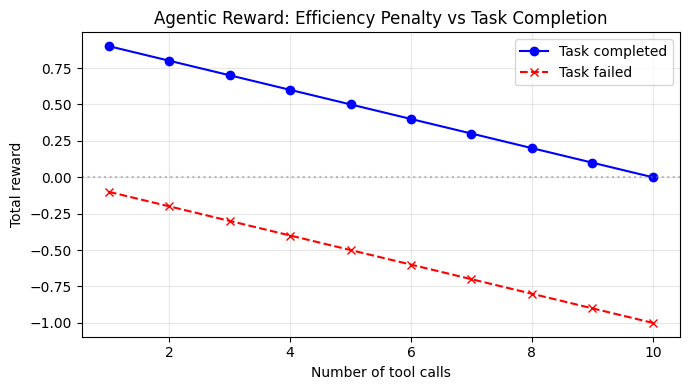

In [23]:
n_calls_range = list(range(1, 11))
total_rewards_success  = [agentic_reward([('calculate', 'x')]*n, True)['total']  for n in n_calls_range]
total_rewards_fail     = [agentic_reward([('calculate', 'x')]*n, False)['total'] for n in n_calls_range]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_calls_range, total_rewards_success, 'b-o', label='Task completed')
ax.plot(n_calls_range, total_rewards_fail,    'r--x', label='Task failed')
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Number of tool calls')
ax.set_ylabel('Total reward')
ax.set_title('Agentic Reward: Efficiency Penalty vs Task Completion')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('agentic_reward.png', dpi=120)
plt.show()

## 9. Reward Component Bar Chart


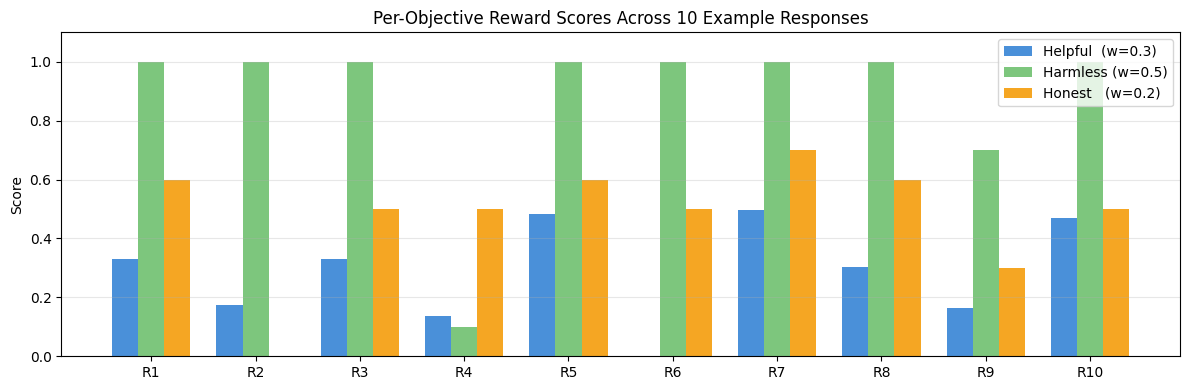

In [24]:
labels = [f'R{i+1}' for i in range(len(EXAMPLE_RESPONSES))]
h_arr  = [s['helpful']  for s in scores]
ha_arr = [s['harmless'] for s in scores]
ho_arr = [s['honest']   for s in scores]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - width, h_arr,  width, label='Helpful  (w=0.3)', color='#4a90d9')
ax.bar(x,         ha_arr, width, label='Harmless (w=0.5)', color='#7dc67d')
ax.bar(x + width, ho_arr, width, label='Honest   (w=0.2)', color='#f5a623')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Per-Objective Reward Scores Across 10 Example Responses')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('multiobjective_bars.png', dpi=120)
plt.show()

## 10. Summary

| Topic | Key takeaway |
|---|---|
| **Weighted sum** | Simple but conflates objectives; hard to interpret which objective drove the reward |
| **Pareto frontier** | Reveals true trade-off; best design choice depends on context |
| **Constraint filtering** | Hard constraints (safety floor) + soft optimisation (maximise helpfulness) |
| **Reward hacking** | Each individual reward function can be gamed; use robust proxies and adversarial testing |
| **Agentic rewards** | Efficiency penalties are essential: without them, agents over-call tools |

**Chapter 16** shows how these reward principles apply to specific domains: code execution, symbolic math, tool-calling APIs, and dialogue quality.
